# Milestone 4 work

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier

## Google Ads

### Multivariate Analysis

In [2]:
google = pd.read_csv("Digital_Marketing_Campaign_Dataset.csv")

In [12]:
google.drop(columns=["CustomerID", "AdvertisingPlatform", "AdvertisingTool"])

,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21,Male,24849,Email,Awareness,8518.308575,0.243792,0.116773,23,9.693602,14.227794,70,13,6,7,286,0
7996,43,Female,44718,SEO,Retention,1424.613446,0.236740,0.190061,49,9.499010,3.501106,52,13,1,5,1502,0
7997,28,Female,125471,Referral,Consideration,4609.534635,0.056526,0.133826,35,2.853241,14.618323,38,16,0,3,738,1
7998,19,Female,107862,PPC,Consideration,9476.106354,0.023961,0.138386,49,1.002964,3.876623,86,1,5,7,2709,1


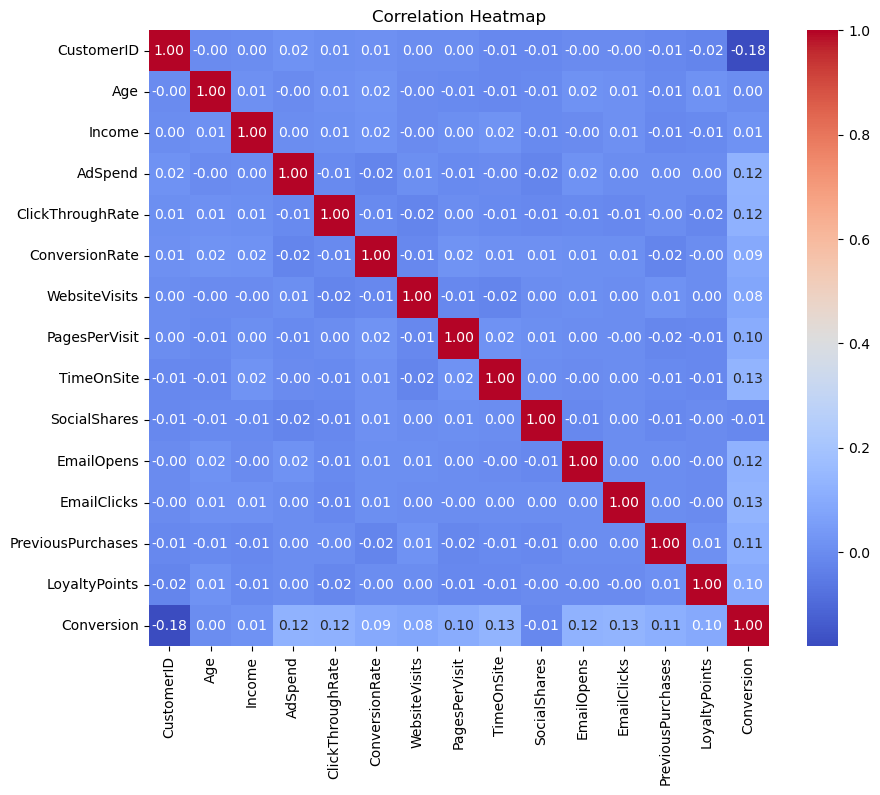

In [5]:
plt.figure(figsize=(10,8))
corr = google.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
google["AdvertisingTool"].unique()

array(['ToolConfid'], dtype=object)

In [24]:
X = google.select_dtypes(include="number").drop(columns=["CustomerID", "Conversion"])
y = google["Conversion"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

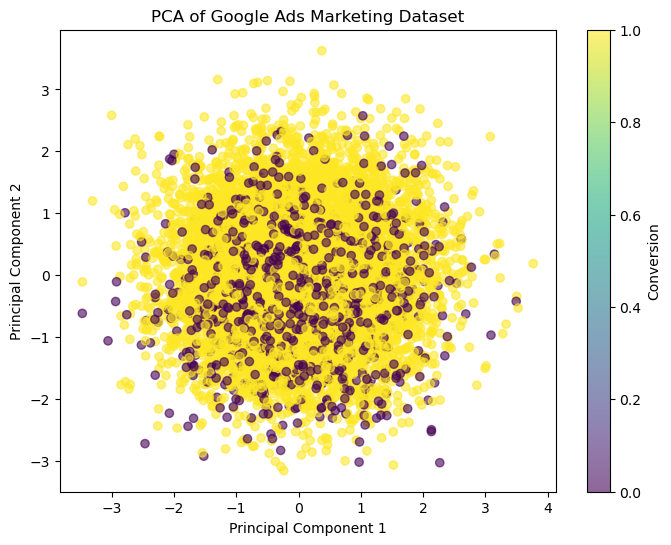

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Google Ads Marketing Dataset")
plt.colorbar(label="Conversion")

plt.show()

The PCA visualization shows that converted and non-converted users are highly overlapping across the first two principal components, with no clear separation between the groups. There is no distinct clustering along the first principal component (PC1), indicating that it does not strongly distinguish conversion behavior on its own. Similarly, the second principal component (PC2) does not reveal any meaningful separation, suggesting that it contributes limited predictive insight in a two-dimensional space. Overall, this pattern indicates that conversion is not driven by a simple linear combination of features, but rather by complex interactions between multiple variables—such as user engagement, marketing activity, and customer behavior—that cannot be easily captured in just two principal components.

In [26]:
print(pca.explained_variance_ratio_)


[0.08334769 0.08019936]


The first two principal components explains approximately 16.5% of the total variance which shows that the dataset is highly complex and cannot be fully represented in the two dimensions. 

In [28]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

print(loadings)

                        PC1       PC2
Age                0.027908  0.620259
Income             0.268017  0.290593
AdSpend           -0.281842  0.165613
ClickThroughRate   0.096966  0.112771
ConversionRate     0.424146  0.309094
WebsiteVisits     -0.350045 -0.015483
PagesPerVisit      0.386249 -0.124469
TimeOnSite         0.350177 -0.148848
SocialShares       0.207986 -0.349956
EmailOpens        -0.100194  0.408233
EmailClicks        0.051496  0.175666
PreviousPurchases -0.392558 -0.114737
LoyaltyPoints     -0.232930  0.155294


### Random Forest Regression

In [32]:
X = pd.get_dummies(google.drop(columns=["Conversion", "CustomerID"]), drop_first=True)
y = google["Conversion"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.888125
Precision: 0.8887476160203432
Recall: 0.9971469329529244
F1 Score: 0.9398319327731093
ROC AUC: 0.8124234499056182

Confusion Matrix:
 [[  23  175]
 [   4 1398]]

Report:
               precision    recall  f1-score   support

           0       0.85      0.12      0.20       198
           1       0.89      1.00      0.94      1402

    accuracy                           0.89      1600
   macro avg       0.87      0.56      0.57      1600
weighted avg       0.88      0.89      0.85      1600



PagesPerVisit        0.094346
TimeOnSite           0.089169
ClickThroughRate     0.087416
AdSpend              0.086181
ConversionRate       0.085233
LoyaltyPoints        0.081802
WebsiteVisits        0.065659
EmailOpens           0.062652
PreviousPurchases    0.061739
Income               0.057676
dtype: float64


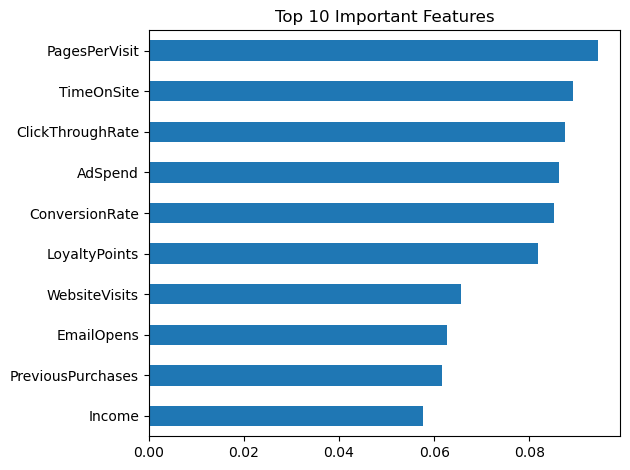

In [37]:
importances = pd.Series(rf.feature_importances_, index=X.columns)\
               .sort_values(ascending=False)

print(importances.head(10))
importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()

In [39]:
cv_f1 = cross_val_score(rf, X, y, cv=5, scoring="f1")
print("CV F1 (mean):", cv_f1.mean())

CV F1 (mean): 0.9405415133298183


A Random Forest classifier was implemented to model conversion outcomes and identify the most important factors influencing user behavior. The model achieved an overall accuracy of 0.888 and an F1 score of 0.94, indicating strong predictive performance. Additionally, the model demonstrated an exceptionally high recall of 0.997 for the conversion class, meaning it successfully identified nearly all users who converted. The ROC-AUC score of 0.81 further suggests that the model has a solid ability to distinguish between converted and non-converted users.

However, a deeper evaluation of the classification report and confusion matrix reveals an important limitation. While the model performs very well in predicting conversions, it struggles to correctly identify non-converted users. Specifically, the recall for the non-conversion class is only 0.12, with a large number of false positives (175 cases). This indicates that the model is biased toward predicting the majority class, which is conversion, due to the significant class imbalance in the dataset. As a result, the model tends to overestimate conversion likelihood, which could lead to inefficient marketing strategies if used without adjustment.

Feature importance analysis provides further insight into the drivers of conversion. The most influential variables include pages per visit (0.094), time on site (0.089), and click-through rate (0.087), all of which reflect user engagement and interaction with digital content. Additional important features include ad spend (0.086) and conversion rate (0.085), suggesting that both marketing investment and campaign effectiveness contribute significantly to conversion outcomes.

In contrast, demographic and historical variables such as income (0.058) and previous purchases (0.062) were less influential, indicating that conversion behavior is driven more by real-time engagement than by static user characteristics. This highlights the importance of optimizing user experience and increasing interaction with marketing channels to improve conversion rates.

These findings align with the earlier PCA analysis, which showed that conversion behavior is influenced by multiple interacting features rather than a single dominant variable. While PCA demonstrated that the dataset is complex and not easily separable in a low-dimensional space, the Random Forest model was able to capture these non-linear relationships effectively. Overall, this analysis suggests that machine learning models are well-suited for understanding and predicting conversion behavior, although additional steps—such as addressing class imbalance—may be necessary to further improve model performance.


## Github Digital Marketing

In [43]:
git = pd.read_csv("marketing_campaign.csv", sep=";")
git

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,3,0,0,0,0,0,0,3,11,0


In [48]:
git.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [49]:
git.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [60]:
clean_git = git.drop(columns=["ID", "Z_CostContact", "Z_Revenue"]).dropna()

In [61]:
clean_git

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,10,4,7,0,0,0,0,0,0,1
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,2,5,0,0,0,0,0,0,0
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,2,10,4,0,0,0,0,0,0,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,4,6,0,0,0,0,0,0,0
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,3,6,5,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,...,3,4,5,0,0,0,0,0,0,0
2236,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,...,2,5,7,0,0,0,1,0,0,0
2237,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,...,3,13,6,0,1,0,0,0,0,0
2238,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,...,5,10,3,0,0,0,0,0,0,0


In [62]:
clean_git.isnull().sum()

Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64

In [58]:
clean_git["Complain"].unique()

array([0, 1])

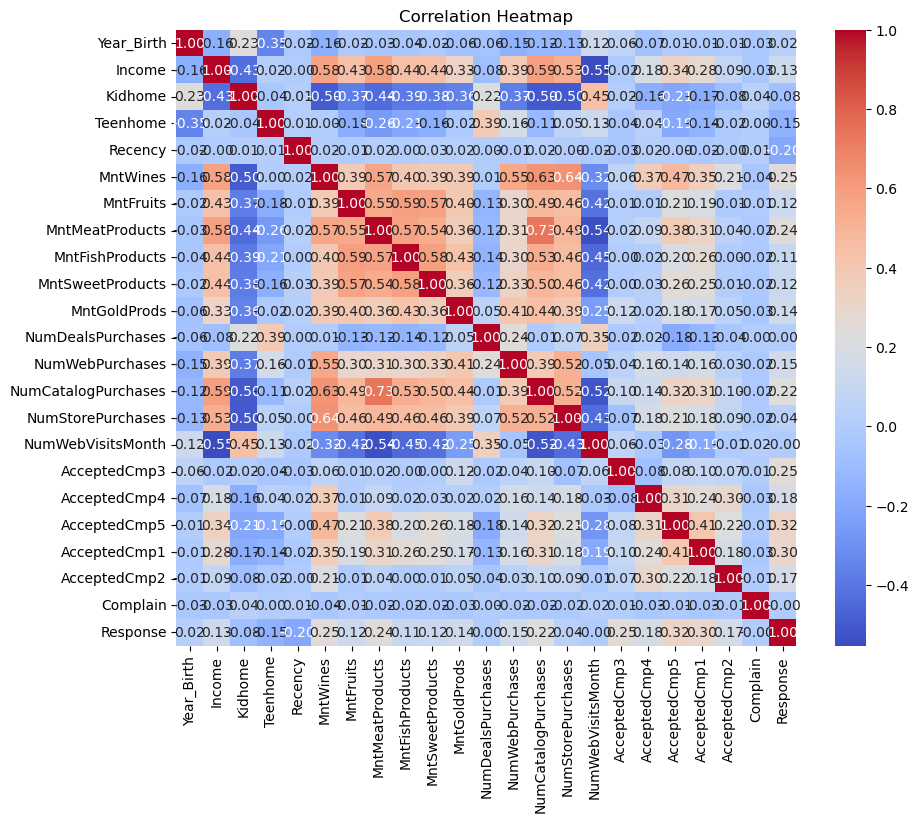

In [63]:
plt.figure(figsize=(10,8))
corr = clean_git.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

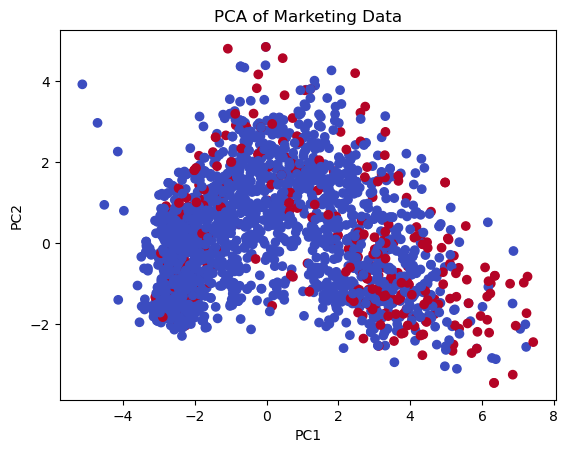

In [67]:
X = clean_git.drop(columns=["Response"]).select_dtypes(include="number")
y = clean_git["Response"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="coolwarm")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Marketing Data")
plt.show()

### Random Forest Classification


Accuracy: 0.8738738738738738
ROC AUC: 0.8620887604418227

Confusion Matrix:
 [[368   9]
 [ 47  20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93       377
           1       0.69      0.30      0.42        67

    accuracy                           0.87       444
   macro avg       0.79      0.64      0.67       444
weighted avg       0.86      0.87      0.85       444



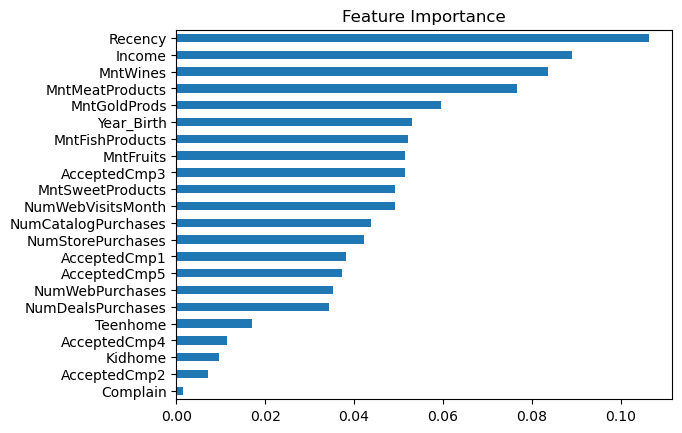

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.show()